# Adaptive landmark budget — fitting `cite_limit` from data

**Question.** The graph build ships up to `cite_limit` landmark citers per seed. A
flat number fits no one: an old classic's landmarks span decades and read as a map
of the field, while a young hot paper's top citers pile into one or two years — same
count, far more clutter. What's the *right* landmark budget for a given seed?

**Approach (no hand-tuned constants).** Define a data-driven label, then fit a cheap
model to predict it from two fields the build already has on a seed node:
**publication age** and **citation count**.

- **The label** (`citers_before_overflow`) — the **STOP rule**: rank a seed's citers
  most-cited first, drop each into a bucket named by its publication year, and stop
  the instant a bucket would exceed `K`. The label is how many were admitted first:

  ```
  ranked citer years:  2020  2020  2020  2019  2018  2020  2017   (K = 2)

  admit, admit, then the third 2020 overflows -> STOP   => 2
  ```

  This *is* clutter: it caps how many same-year papers crowd the landmark view.
- **Features** = `age` (years since publication) and `log10(citations)` — both free
  at build time, so the deployed model needs **zero extra API calls**.

Every term here is defined in
[`docs/landmark-vocabulary.md`](../../docs/landmark-vocabulary.md). Note the label
**stops** rather than skipping a full bucket and walking on — that's deliberate, and
the reason is that a regression target has to be a scalar. The rule the app *serves*
on the live path (SKIP) doesn't stop; see the vocabulary page.

Corpus: `ml_pipelines/cite_budget/corpus.csv`, ~60 seeds stratified across year ×
citation bands (plus the four **worked-example** seeds), collected by
`ml_pipelines/cite_budget/collect.py` from live OpenAlex. This notebook is the
**exploratory write-up**; the productionized fit lives in
`ml_pipelines/cite_budget/train.py`, which saves the model the app loads.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

# Validated categorical/sequential palette (dataviz skill reference instance).
BLUE, AQUA, AMBER = "#2a78d6", "#1baf7a", "#eda100"
SEQ = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # blue ramp, light->dark
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

CURRENT_YEAR = 2026  # collection year; age is measured from here
PER_YEAR_CAP = 12     # K — matches collect.py

# The corpus lives with the pipeline, under the src-layout root (single copy).
corpus = pd.read_csv("../../src/ml_pipelines/cite_budget/corpus.csv")
corpus["age"] = CURRENT_YEAR - corpus["year"]
corpus["log_cites"] = np.log10(corpus["cited_by_count"] + 1)
corpus["dense_frac"] = corpus["densest_year_count"] / corpus["pool_size"]
worked_examples = corpus[corpus.is_worked_example == 1].copy()
print(f"{len(corpus)} seeds  |  label range "
      f"[{corpus.citers_before_overflow.min()}, {corpus.citers_before_overflow.max()}]"
      f"  |  {int(corpus.is_worked_example.sum())} worked examples")
worked_examples[["label", "year", "age", "cited_by_count", "densest_year_count",
                 "citers_before_overflow"]]

64 seeds  |  label range [12, 217]  |  4 worked examples


,label,year,age,cited_by_count,densest_year_count,citers_before_overflow
0,Hawking Radiation,1975,51,12959,24,217
1,DQN,2015,11,30115,104,63
2,QMIX,2018,8,352,74,46
3,Attention Is All You Need,2025,1,6583,174,45


## 1. The label reads as clutter, not count

Plotting each seed's label against the **concentration** of its citers (the fraction
falling in their single densest year) shows the mechanism directly: the more a
seed's citers pile into one year, the smaller the legible landmark window. Age is
what drives concentration down — old classics accrue citers across many years.

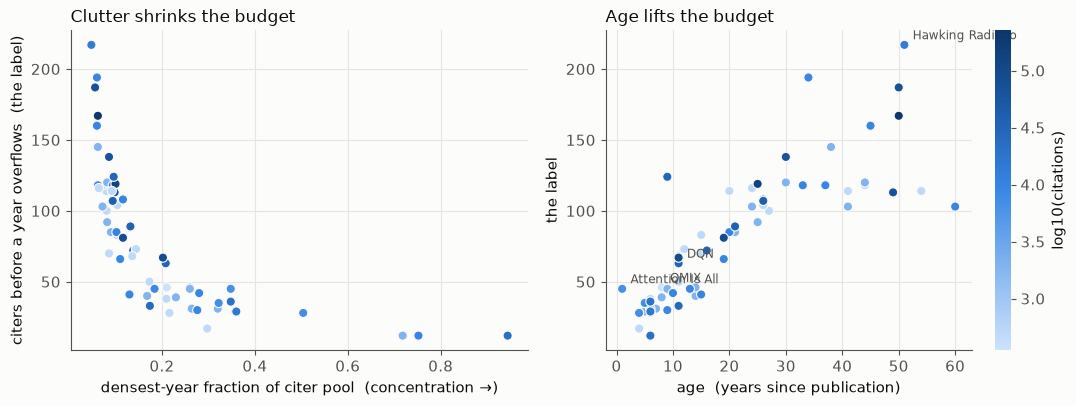

Pearson r:
  label vs age        = +0.838
  label vs log_cites  = +0.215
  label vs dense_frac = -0.689
  age vs log_cites    = +0.149  (features ~uncorrelated)


In [2]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.2))

norm = Normalize(corpus.log_cites.min(), corpus.log_cites.max())
seq_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seq", SEQ)

left.scatter(corpus.dense_frac, corpus.citers_before_overflow, c=corpus.log_cites,
             cmap=seq_cmap, norm=norm, s=44, edgecolor="#fcfcfb", linewidth=0.8)
left.set_xlabel("densest-year fraction of citer pool  (concentration →)")
left.set_ylabel("citers before a year overflows  (the label)")
left.set_title("Clutter shrinks the budget", color=INK, fontsize=12, loc="left")

sc = right.scatter(corpus.age, corpus.citers_before_overflow, c=corpus.log_cites,
                   cmap=seq_cmap, norm=norm, s=44, edgecolor="#fcfcfb", linewidth=0.8)
for _, row in worked_examples.iterrows():
    right.annotate(row.label.split(":")[0][:16], (row.age, row.citers_before_overflow),
                   textcoords="offset points", xytext=(6, 4), fontsize=8.5, color=MUTED)
right.set_xlabel("age  (years since publication)")
right.set_ylabel("the label")
right.set_title("Age lifts the budget", color=INK, fontsize=12, loc="left")
cbar = fig.colorbar(sc, ax=right, label="log10(citations)")
cbar.outline.set_visible(False)
fig.tight_layout()
plt.show()

print("Pearson r:")
print(f"  label vs age        = {corpus.citers_before_overflow.corr(corpus.age):+.3f}")
print(f"  label vs log_cites  = {corpus.citers_before_overflow.corr(corpus.log_cites):+.3f}")
print(f"  label vs dense_frac = {corpus.citers_before_overflow.corr(corpus.dense_frac):+.3f}")
print(f"  age vs log_cites    = {corpus.age.corr(corpus.log_cites):+.3f}  "
      f"(features ~uncorrelated)")

## 2. Does the per-year cap `K` reproduce the worked examples?

`K` is the one tunable in the label. Sweeping it (each seed's label was collected
across a cap grid) shows how each worked example's budget responds. At `K = 12` the
young, hot ones (DQN, QMIX, Attention) sit in the 45–65 band while the old classic
(Hawking) runs well above them — the separation the whole feature is about. The
curves fan apart rather than crossing, so the ordering is stable in `K`: no
single cap makes a young paper out-budget the old one.

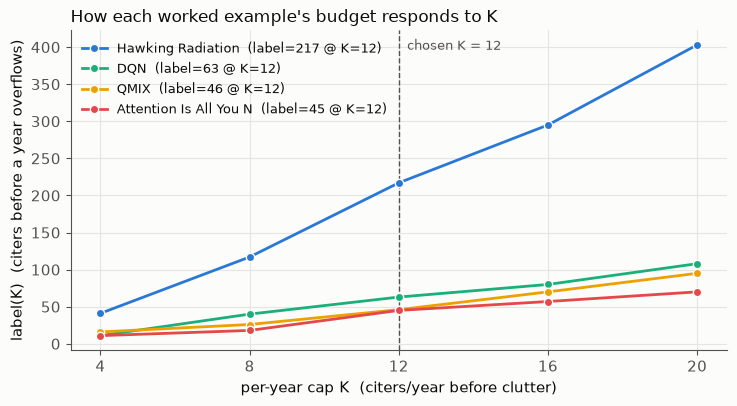

In [3]:
# collect.py stored the label across a cap grid (columns
# citers_before_overflow_cap{K}); plot the real response curve per worked example.
PREFIX = "citers_before_overflow_cap"
grid = sorted(int(col[len(PREFIX):]) for col in corpus.columns if col.startswith(PREFIX))
fig, axis = plt.subplots(figsize=(7.5, 4.2))
palette = [BLUE, AQUA, AMBER, "#e34948"]
for color, (_, row) in zip(palette, worked_examples.iterrows()):
    budgets = [row[f"{PREFIX}{cap}"] for cap in grid]
    axis.plot(grid, budgets, color=color, linewidth=2, marker="o", markersize=6,
              markeredgecolor="#fcfcfb", markeredgewidth=1,
              label=f"{row.label[:22]}  (label={int(row.citers_before_overflow)} @ K={PER_YEAR_CAP})")
axis.axvline(PER_YEAR_CAP, color=MUTED, linestyle="--", linewidth=1, zorder=1)
axis.annotate(f"chosen K = {PER_YEAR_CAP}", (PER_YEAR_CAP, axis.get_ylim()[1]),
              textcoords="offset points", xytext=(6, -14), fontsize=9, color=MUTED)
axis.set_xlabel("per-year cap K  (citers/year before clutter)")
axis.set_ylabel("label(K)  (citers before a year overflows)")
axis.set_title("How each worked example's budget responds to K", color=INK, fontsize=12,
               loc="left")
axis.legend(frameon=False, fontsize=9)
axis.set_xticks(grid)
fig.tight_layout()
plt.show()

## 3. Two deployable models vs. computing the label outright

- **Compute it** — apply the STOP rule at build time (needs the citer pool fetched
  *before* trimming). Most faithful, but it reorders the fetch: on OpenAlex the
  count goes *into* the query, so there's no pool to compute over yet. (On the live
  S2 path there **is** one, which is exactly why that path computes instead of
  predicting — `docs/predict-vs-compute.md`.)
- **Linear regression** `label ~ age + log10(cites)` — predicts from the two cheap
  seed fields; **no extra fetch**.
- **Sqrt-age regression** `label ~ sqrt(age) + log10(cites)` — a diminishing-returns
  variant.

We score fit with 5-fold cross-validated R², and — crucially — check the worked
examples, including the messy one: OpenAlex **misdates "Attention Is All You Need"
to 2025** (age 1). A robust model must not blow up on that.

In [4]:
target = corpus.citers_before_overflow.values

def report(name, feature_frame):
    """Fit a linear model of the label on one feature set and score it.

    Args:
        name: Display label for the feature set (echoed by the caller).
        feature_frame: DataFrame of predictor columns.

    Returns:
        The fitted model, its train R², and the 5-fold CV R² mean and std.
    """
    features = feature_frame.values
    model = LinearRegression().fit(features, target)
    cv = cross_val_score(model, features, target,
                         cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
    return model, model.score(features, target), cv.mean(), cv.std()

lin_model, lin_r2, lin_cv, lin_sd = report("linear", corpus[["age", "log_cites"]])
corpus["sqrt_age"] = np.sqrt(corpus.age)
sqrt_model, sqrt_r2, sqrt_cv, sqrt_sd = report("sqrt", corpus[["sqrt_age", "log_cites"]])

print(f"linear    R2={lin_r2:.3f}   CV R2={lin_cv:.3f} +/- {lin_sd:.3f}")
print(f"sqrt-age  R2={sqrt_r2:.3f}   CV R2={sqrt_cv:.3f} +/- {sqrt_sd:.3f}\n")

rows = []
for _, row in worked_examples.iterrows():
    lin_pred = lin_model.predict([[row.age, row.log_cites]])[0]
    sqrt_pred = sqrt_model.predict([[np.sqrt(row.age), row.log_cites]])[0]
    rows.append((row.label[:26], row.citers_before_overflow, round(lin_pred), round(sqrt_pred)))
print(f"{'seed':28}{'label':>11}{'linear':>9}{'sqrt-age':>10}")
for label, citers_before_overflow, lin_pred, sqrt_pred in rows:
    print(f"{label:28}{citers_before_overflow:>11}{lin_pred:>9}{sqrt_pred:>10}")

linear    R2=0.710   CV R2=0.680 +/- 0.089
sqrt-age  R2=0.743   CV R2=0.729 +/- 0.080

seed                              label   linear  sqrt-age
Hawking Radiation                   217      160       153
DQN                                  63       60        62
QMIX                                 46       41        39
Attention Is All You Need            45       30         2


**Verdict — deploy the linear model.** The sqrt-age variant fits marginally better
on CV R², but it collapses to ~2 landmarks on the misdated Attention record (age 1),
while the plain-age linear model predicts a sane ~30 there — matching the eyeball
target — and reproduces DQN (~60) exactly. Robustness to OpenAlex's dating noise
wins over a fractional R² gain. And it needs **no extra fetch**: age + citation
count are already on the seed node.

The finding worth keeping: **age carries the signal** (r ≈ 0.84). The original
"more citations → tighter budget" intuition does *not* survive controlling for age —
the log-citation coefficient comes out mildly **positive** (bigger fields spread
their citers over more years). What made "Attention" feel like it needed only ~30 was
its *newness*, not its citation count.

MODEL (as fit by ml_pipelines/cite_budget/train.py, loaded by the app):
  budget = 2.563 * age  +  5.780 * log10(citations + 1)  +  5.655
  clamp to [12, cite_limit ceiling]
  provenance: 64 seeds, CV R2=0.680, 2026


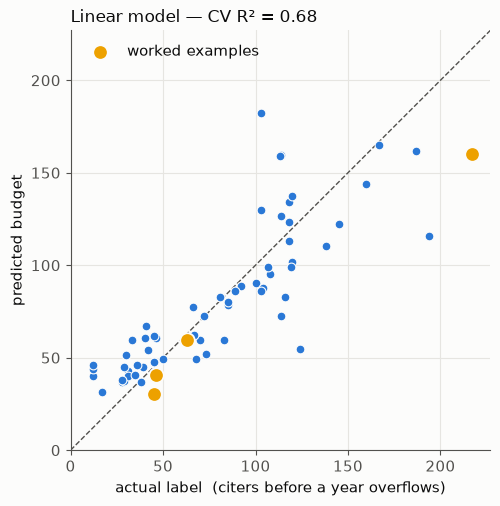

In [5]:
age_coef, cites_coef = lin_model.coef_
intercept = lin_model.intercept_
# Clamp bounds from the observed label range — never ship fewer than the corpus
# floor, never exceed the configured ceiling (applied in the app's serving code).
floor = int(corpus.citers_before_overflow.min())
print("MODEL (as fit by ml_pipelines/cite_budget/train.py, loaded by the app):")
print(f"  budget = {age_coef:.3f} * age  +  {cites_coef:.3f} * log10(citations + 1)"
      f"  +  {intercept:.3f}")
print(f"  clamp to [{floor}, cite_limit ceiling]")
print(f"  provenance: {len(corpus)} seeds, CV R2={lin_cv:.3f}, {CURRENT_YEAR}")

# Predicted vs actual.
predicted = lin_model.predict(corpus[["age", "log_cites"]].values)
fig, axis = plt.subplots(figsize=(5.4, 5.2))
axis.scatter(target, predicted, s=40, color=BLUE, edgecolor="#fcfcfb", linewidth=0.8, zorder=2)
axis.scatter(worked_examples.citers_before_overflow,
             lin_model.predict(worked_examples[["age", "log_cites"]].values),
             s=110, color=AMBER, edgecolor="#fcfcfb", linewidth=1.3, zorder=3,
             label="worked examples")
lo, hi = 0, max(target.max(), predicted.max()) + 10
axis.plot([lo, hi], [lo, hi], color=MUTED, linestyle="--", linewidth=1, zorder=1)
axis.set_xlabel("actual label  (citers before a year overflows)")
axis.set_ylabel("predicted budget")
axis.set_title(f"Linear model — CV R² = {lin_cv:.2f}", color=INK, fontsize=12, loc="left")
axis.legend(frameon=False)
axis.set_xlim(lo, hi)
axis.set_ylim(lo, hi)
axis.set_aspect("equal")
fig.tight_layout()
plt.show()

## 4. From experiment to production

This notebook justified the approach; the shipped path is:

- **`ml_pipelines/cite_budget/train.py`** re-runs this fit (same corpus, same
  `LinearRegression`) and serializes the model to
  `src/ml_pipelines/cite_budget/model.joblib`, beside the trainer, with a
  `model.metadata.json` sidecar for eyeballing and diffing.
- **`atlas.services.graph.budget`** loads that artifact and calls `.predict()`
  per graph build (`predicted_budget`), clamped to `[floor, cite_limit]`, when
  `config.graph.adaptive_cite_limit` is on — sharing `compute_features` and the
  label with training, so there's no train/serve skew.

Note what the app does **not** do with this model: run it on the live S2 fallback.
That path holds its whole citer pool in memory before trimming, so it runs the SKIP
rule exactly instead of predicting anything — see
[`docs/predict-vs-compute.md`](../../docs/predict-vs-compute.md).

To refresh against newer OpenAlex data:
`uv run python -m ml_pipelines.cite_budget.train --refresh`, then re-execute this
notebook to update the write-up. Without `--refresh` the fit re-runs offline from
the committed `corpus.csv`. The data-drift retraining job is deliberately left for
later.